# Notebook 01 : Exploration des Données Orange Tunisie

**PFE 2026 - Malek - ESB**

## Objectifs

Ce notebook réalise une **analyse exploratoire** (EDA - Exploratory Data Analysis) 
des données du Data Warehouse `orange_dwh` :

1. Connexion à PostgreSQL
2. Chargement des 8 tables du DWH
3. Statistiques descriptives
4. Premières visualisations
5. Identification de patterns et insights

## Bibliothèques utilisées

- **pandas** : Manipulation des données
- **numpy** : Calculs numériques
- **matplotlib** : Graphiques de base
- **seaborn** : Graphiques statistiques avancés
- **sqlalchemy** : Connexion PostgreSQL

In [1]:
# === 1. IMPORTS DES BIBLIOTHEQUES ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib pour notebooks
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Style Orange (couleurs de la charte)
ORANGE_COLORS = ['#FF6600', '#FF7A1A', '#FF8E33', '#FFA24D', '#FFB666']
sns.set_palette(ORANGE_COLORS)

print("Bibliothèques chargées avec succès !")
print(f"pandas : {pd.__version__}")
print(f"numpy : {np.__version__}")
print(f"matplotlib : {plt.matplotlib.__version__}")
print(f"seaborn : {sns.__version__}")

Bibliothèques chargées avec succès !
pandas : 2.3.3
numpy : 2.3.5
matplotlib : 3.10.6
seaborn : 0.13.2


In [2]:
# === 2. CONNEXION POSTGRESQL ===

# Charger les variables d'environnement
PROJECT_ROOT = Path.cwd().parent  # Remonte d'un niveau (notebooks/ -> projet)
env_path = PROJECT_ROOT / ".env"

if env_path.exists():
    load_dotenv(env_path)
    print(f"Fichier .env trouve : {env_path}")
else:
    print(f"ATTENTION : .env non trouve a {env_path}")

# Recuperer les credentials
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "orange_dwh")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

# Creer le moteur SQLAlchemy
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Tester la connexion
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).fetchone()
    print(f"Connexion OK : {result}")

print(f"\nBase de donnees : {DB_NAME}")
print(f"Hote : {DB_HOST}:{DB_PORT}")
print(f"Utilisateur : {DB_USER}")

Fichier .env trouve : C:\PFE_Orange\projet_orange_pfe\.env
Connexion OK : (1,)

Base de donnees : orange_dwh
Hote : localhost:5432
Utilisateur : postgres


## 1. Inventaire du Data Warehouse

Affichons les 8 tables du DWH avec leur nombre de lignes.

In [3]:
# === INVENTAIRE DES TABLES ===

query_inventaire = """
SELECT 'dim_vendeur'        AS table_name, COUNT(*) AS nb_lignes FROM dim_vendeur
UNION ALL
SELECT 'dim_boutique',       COUNT(*) FROM dim_boutique
UNION ALL
SELECT 'dim_produit',        COUNT(*) FROM dim_produit
UNION ALL
SELECT 'dim_offre',          COUNT(*) FROM dim_offre
UNION ALL
SELECT 'dim_groupe',         COUNT(*) FROM dim_groupe
UNION ALL
SELECT 'dim_ref_objectifs',  COUNT(*) FROM dim_ref_objectifs
UNION ALL
SELECT 'fact_ventes',        COUNT(*) FROM fact_ventes
UNION ALL
SELECT 'fact_objectifs',     COUNT(*) FROM fact_objectifs
ORDER BY nb_lignes DESC;
"""

df_inventaire = pd.read_sql(query_inventaire, engine)
print(f"TOTAL : {df_inventaire['nb_lignes'].sum():,} lignes dans le DWH\n")
df_inventaire

TOTAL : 90,696 lignes dans le DWH



,table_name,nb_lignes
0,fact_ventes,63615
1,dim_vendeur,22001
2,dim_boutique,3168
3,fact_objectifs,1408
4,dim_produit,279
5,dim_offre,180
6,dim_groupe,34
7,dim_ref_objectifs,11


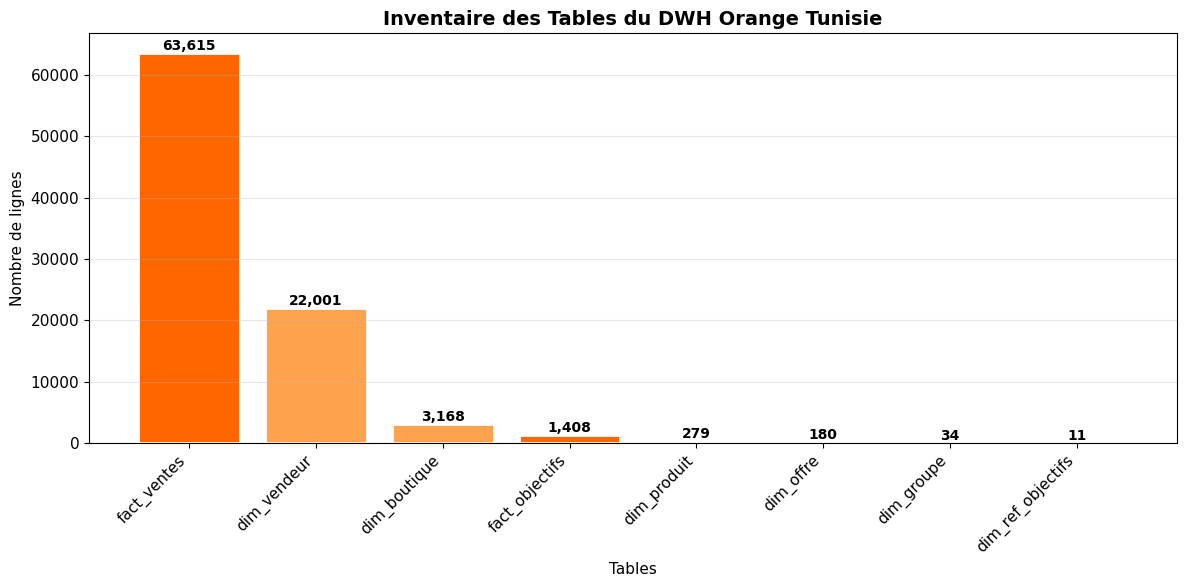


Légende :
  Orange foncé = Tables de FAITS
  Orange clair = Tables de DIMENSIONS


In [4]:
# === VISUALISATION INVENTAIRE ===

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#FF6600' if 'fact' in name else '#FFA24D' 
          for name in df_inventaire['table_name']]

bars = ax.bar(df_inventaire['table_name'], 
              df_inventaire['nb_lignes'], 
              color=colors,
              edgecolor='white',
              linewidth=2)

# Ajouter les valeurs au-dessus
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Inventaire des Tables du DWH Orange Tunisie', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de lignes')
ax.set_xlabel('Tables')
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLégende :")
print("  Orange foncé = Tables de FAITS")
print("  Orange clair = Tables de DIMENSIONS")

## 2. Analyse des Ventes (`fact_ventes`)

La table principale contient 63 615 contrats de vente.

In [5]:
# === CHARGEMENT DE FACT_VENTES ===

df_ventes = pd.read_sql("SELECT * FROM fact_ventes", engine)

print(f"Dimensions : {df_ventes.shape}")
print(f"Colonnes ({len(df_ventes.columns)}) : {list(df_ventes.columns)}\n")

df_ventes.head()

Dimensions : (63615, 14)
Colonnes (14) : ['ventes_id', 'vendeur_key', 'boutique_key', 'produit_key', 'offre_key', 'groupe_key', 'date_vente', 'contrat_souscrit', 'duree_engagement', 'first_month_bill', 'second_month_bill', 'third_month_bill', 'product_number', 'date_creation']



,ventes_id,vendeur_key,boutique_key,produit_key,offre_key,groupe_key,date_vente,contrat_souscrit,duree_engagement,first_month_bill,second_month_bill,third_month_bill,product_number,date_creation
0,335635,75350,3437.0,None,512.0,101,2025-02-10,None,25,1.0,1.0,1.0,43006000003,2026-05-03 13:49:15.929856
1,335636,68181,5673.0,None,392.0,80,2025-02-06,None,24,1.0,1.0,1.0,43008000001,2026-05-03 13:49:15.929856
2,335637,78393,5680.0,None,428.0,100,2025-02-25,None,24,1.0,1.0,1.0,43007000004,2026-05-03 13:49:15.929856
3,335638,68376,3440.0,None,512.0,101,2025-02-15,None,25,1.0,1.0,1.0,43006000003,2026-05-03 13:49:15.929856
4,335639,74817,3432.0,None,379.0,80,2025-03-11,None,24,1.0,1.0,1.0,43008000001,2026-05-03 13:49:15.929856


In [6]:
# === STATISTIQUES DESCRIPTIVES ===

print("=" * 60)
print("STATISTIQUES DESCRIPTIVES - FIRST_MONTH_BILL")
print("=" * 60)

stats = df_ventes['first_month_bill'].describe()
print(stats)

print(f"\nValeurs manquantes : {df_ventes['first_month_bill'].isna().sum()}")
print(f"Valeurs zero       : {(df_ventes['first_month_bill'] == 0).sum()}")
print(f"Valeurs negatives  : {(df_ventes['first_month_bill'] < 0).sum()}")

STATISTIQUES DESCRIPTIVES - FIRST_MONTH_BILL
count    60458.000000
mean         0.945350
std          0.227297
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: first_month_bill, dtype: float64

Valeurs manquantes : 3157
Valeurs zero       : 3304
Valeurs negatives  : 0


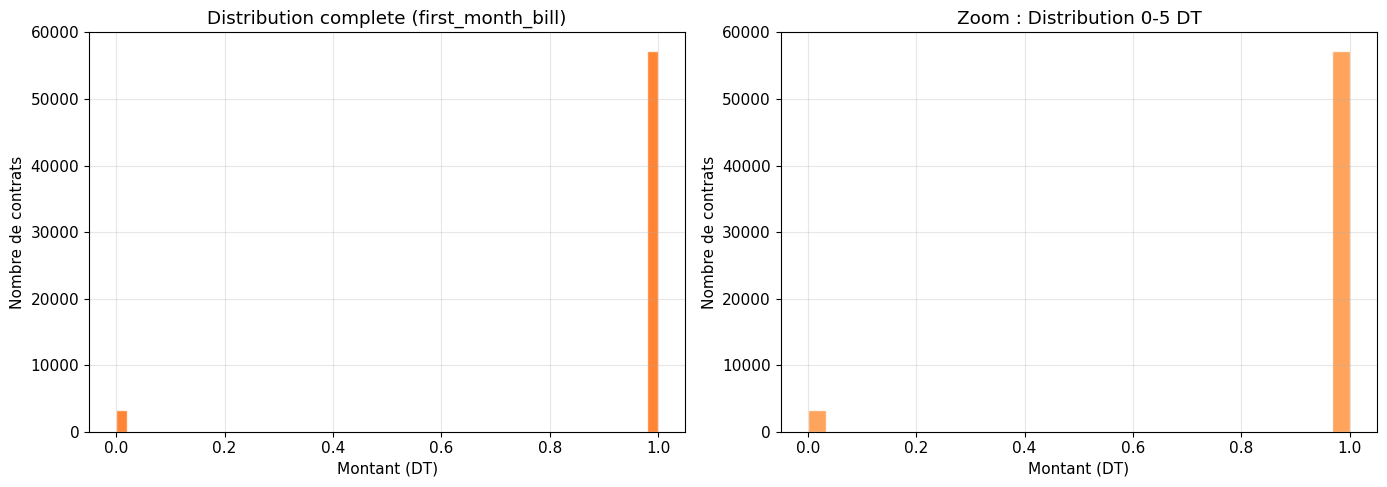


INSIGHT : La majorite des contrats sont a moins de 5 DT
         (frais d'activation et abonnements economiques)


In [7]:
# === DISTRIBUTION DES MONTANTS ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme 1 : Distribution complete
axes[0].hist(df_ventes['first_month_bill'], bins=50, 
             color='#FF6600', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution complete (first_month_bill)')
axes[0].set_xlabel('Montant (DT)')
axes[0].set_ylabel('Nombre de contrats')
axes[0].grid(alpha=0.3)

# Histogramme 2 : Zoom sur 0-5 DT (la majorite)
mask = df_ventes['first_month_bill'] < 5
axes[1].hist(df_ventes.loc[mask, 'first_month_bill'], bins=30,
             color='#FF8E33', edgecolor='white', alpha=0.8)
axes[1].set_title('Zoom : Distribution 0-5 DT')
axes[1].set_xlabel('Montant (DT)')
axes[1].set_ylabel('Nombre de contrats')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINSIGHT : La majorite des contrats sont a moins de 5 DT")
print("         (frais d'activation et abonnements economiques)")

## 3. Top 10 Vendeurs

Identifions les vendeurs les plus performants.

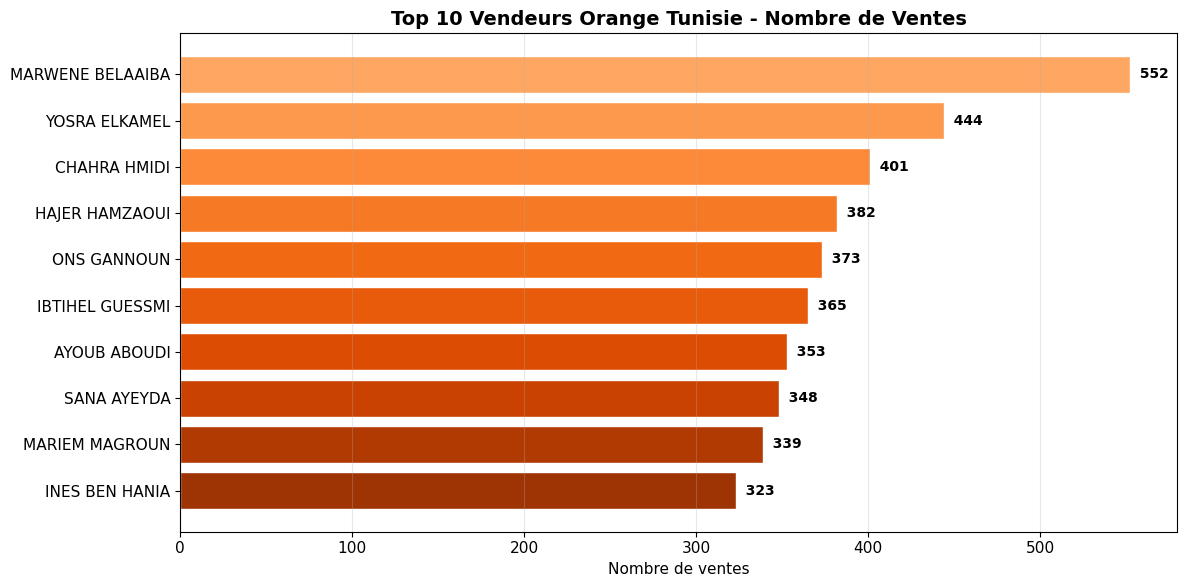


TOP 3 :
   1. MARWENE BELAAIBA          : 552 ventes
   2. YOSRA ELKAMEL             : 444 ventes
   3. CHAHRA HMIDI              : 401 ventes


In [8]:
# === TOP 10 VENDEURS ===

query_top_vendeurs = """
SELECT 
    v.seller_name AS vendeur,
    COUNT(*) AS nb_ventes,
    ROUND(SUM(f.first_month_bill)::numeric, 2) AS ca_total
FROM fact_ventes f
JOIN dim_vendeur v ON f.vendeur_key = v.vendeur_key
GROUP BY v.seller_name
ORDER BY nb_ventes DESC
LIMIT 10;
"""

df_top = pd.read_sql(query_top_vendeurs, engine)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))

colors_gradient = plt.cm.Oranges(np.linspace(0.4, 0.9, len(df_top)))

bars = ax.barh(df_top['vendeur'], df_top['nb_ventes'], 
                color=colors_gradient, edgecolor='white', linewidth=1)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'  {int(width):,}',
            ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Vendeurs Orange Tunisie - Nombre de Ventes', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Nombre de ventes')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTOP 3 :")
for i, row in df_top.head(3).iterrows():
    print(f"   {i+1}. {row['vendeur']:<25} : {row['nb_ventes']:,} ventes")